In [ ]:
# !pip install simple-icd-10
# !pip install seaborn

In [3]:
import os
import pandas as pd
import json
import re
import simple_icd_10 as icd
from tqdm import tqdm
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 1000)

In [4]:
# MODEL = "qwen3-235b-a22b"
# MODEL = "GPT_OSS_MODEL_SIZE.BIG_Low"
MODEL = "GPT_OSS_MODEL_SIZE.SMALL_Low"
ICD_CODE = "C61"
TRY = 0
RESPONSES_PATH = f"outputs_mcq/responses_{MODEL}_{ICD_CODE}_{TRY}.tsv"

In [8]:
responses = pd.read_csv(RESPONSES_PATH, sep="\t").drop(columns=["Unnamed: 0"], errors="ignore")

In [9]:
responses.head()

,icd10_category_1,icd10_category_2,response
0,C61,K76,B
1,C61,R18,B
2,C61,K74,B
3,C61,B19,B
4,C61,J44,B


In [10]:
responses.count()

icd10_category_1    3392
icd10_category_2    3392
response            3392
dtype: int64

In [ ]:
N_CODES = len(responses)//2
assert responses['icd10_category_1'].value_counts()['C61'] == N_CODES + 1
assert responses['icd10_category_2'].value_counts()['C61'] == N_CODES + 1
assert set(responses["response"].value_counts().index.tolist()) == set(["A", "B"])

In [17]:
responses["score"] = responses["response"].map({"A": 1, "B": 0})

In [25]:
probs = responses[["icd10_category_1", "icd10_category_2", "score"]].iloc[:N_CODES].copy(deep=True)
probs = pd.merge(
    probs,
    responses[["icd10_category_1", "icd10_category_2", "score"]].iloc[N_CODES:],
    how="inner",
    left_on=["icd10_category_1", "icd10_category_2"],
    right_on=["icd10_category_2", "icd10_category_1"],
    suffixes=("_1", "_2"),
)
assert len(probs) == N_CODES

In [26]:
probs.head(2)

,icd10_category_1_1,icd10_category_2_1,score_1,icd10_category_1_2,icd10_category_2_2,score_2
0,C61,K76,0,K76,C61,0
1,C61,R18,0,R18,C61,0


In [27]:
probs.rename(columns={"icd10_category_1_1": "icd10_category_1", "icd10_category_2_1": "icd10_category_2"}, inplace=True)
probs.drop(columns=["icd10_category_1_2", "icd10_category_2_2"], inplace=True)
probs['score'] = probs[['score_1', 'score_2']].mean(axis=1)
probs.drop(columns=['score_1', 'score_2'], inplace=True)

In [28]:
probs.head(2)

,icd10_category_1,icd10_category_2,score
0,C61,K76,0.0
1,C61,R18,0.0


In [33]:
probs['score'].value_counts()

score
0.0    1642
0.5      52
1.0       2
Name: count, dtype: int64

<Axes: >

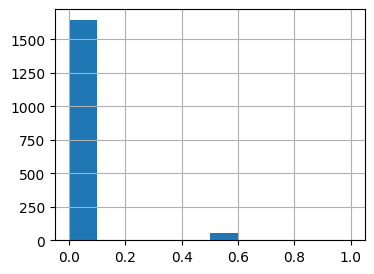

In [32]:
probs['score'].hist(figsize=(4, 3), bins=np.arange(0, 1.1, 0.1))

In [34]:
if not os.path.exists("scores_mcq/"): os.makedirs("scores_mcq/")
probs.to_csv(f"scores_mcq/scores_{MODEL}_{ICD_CODE}_{TRY}.csv")